In [ ]:
 
!pip install numpy pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset (example CSV file)
df = pd.read_csv(r"C:\Users\new\Downloads\Student_Lab.csv")
df

,Unnamed: 0,Id,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,0,5001,21,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No,AA
1,1,5002,20,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes,AA
2,2,5003,21,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes,AA
3,3,5004,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No,AA
4,4,5005,22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes,AA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,140,5141,22,Female,State,50%,Yes,Yes,Private,0,Always,No,Yes,No,Yes,CC
141,141,5142,18,Female,State,75%,No,No,Private,0,Never,No,Yes,Yes,No,CC
142,142,5143,18,Female,Private,75%,No,No,Private,0,Always,Yes,No,No,No,AA
143,143,5144,22,Female,State,75%,Yes,Yes,Bus,12,Sometimes,No,Yes,No,Yes,CB


In [7]:
# First 5 rows
df.head()

# Last 5 rows
df.tail()

,Unnamed: 0,Id,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
140,140,5141,22,Female,State,50%,Yes,Yes,Private,0,Always,No,Yes,No,Yes,CC
141,141,5142,18,Female,State,75%,No,No,Private,0,Never,No,Yes,Yes,No,CC
142,142,5143,18,Female,Private,75%,No,No,Private,0,Always,Yes,No,No,No,AA
143,143,5144,22,Female,State,75%,Yes,Yes,Bus,12,Sometimes,No,Yes,No,Yes,CB
144,144,5145,18,Female,Private,100%,No,No,Private,12,Always,Yes,No,Yes,No,BB


In [8]:
# Shape of dataset
print("Shape of dataset:", df.shape)

# Column names
print("Columns:", df.columns)

Shape of dataset: (145, 16)
Columns: Index(['Unnamed: 0', 'Id', 'Student_Age', 'Sex', 'High_School_Type',
       'Scholarship', 'Additional_Work', 'Sports_activity', 'Transportation',
       'Weekly_Study_Hours', 'Attendance', 'Reading', 'Notes',
       'Listening_in_Class', 'Project_work', 'Grade'],
      dtype='object')


In [9]:
df.describe()


,Unnamed: 0,Id,Student_Age,Weekly_Study_Hours
count,145.000000,145.000000,145.000000,145.000000
mean,72.000000,5073.000000,19.682759,2.331034
std,42.001984,42.001984,1.992010,4.249273
min,0.000000,5001.000000,18.000000,0.000000
25%,36.000000,5037.000000,18.000000,0.000000
50%,72.000000,5073.000000,19.000000,0.000000
75%,108.000000,5109.000000,21.000000,2.000000
max,144.000000,5145.000000,26.000000,12.000000


In [ ]:
df.info() #Column names

# Data types

# Non-null values

# Memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          145 non-null    int64 
 1   Id                  145 non-null    int64 
 2   Student_Age         145 non-null    int64 
 3   Sex                 145 non-null    object
 4   High_School_Type    145 non-null    object
 5   Scholarship         144 non-null    object
 6   Additional_Work     145 non-null    object
 7   Sports_activity     145 non-null    object
 8   Transportation      145 non-null    object
 9   Weekly_Study_Hours  145 non-null    int64 
 10  Attendance          145 non-null    object
 11  Reading             145 non-null    object
 12  Notes               145 non-null    object
 13  Listening_in_Class  145 non-null    object
 14  Project_work        145 non-null    object
 15  Grade               145 non-null    object
dtypes: int64(4), object(12)
me

In [11]:
df.isnull().sum()

Unnamed: 0            0
Id                    0
Student_Age           0
Sex                   0
High_School_Type      0
Scholarship           1
Additional_Work       0
Sports_activity       0
Transportation        0
Weekly_Study_Hours    0
Attendance            0
Reading               0
Notes                 0
Listening_in_Class    0
Project_work          0
Grade                 0
dtype: int64

In [12]:
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\new\AppData\Local\Temp\ipykernel_11016\3991344066.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [13]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['Unnamed: 0', 'Id', 'Student_Age', 'Weekly_Study_Hours'], dtype='object')
Categorical Columns: Index(['Sex', 'High_School_Type', 'Scholarship', 'Additional_Work',
       'Sports_activity', 'Transportation', 'Attendance', 'Reading', 'Notes',
       'Listening_in_Class', 'Project_work', 'Grade'],
      dtype='object')


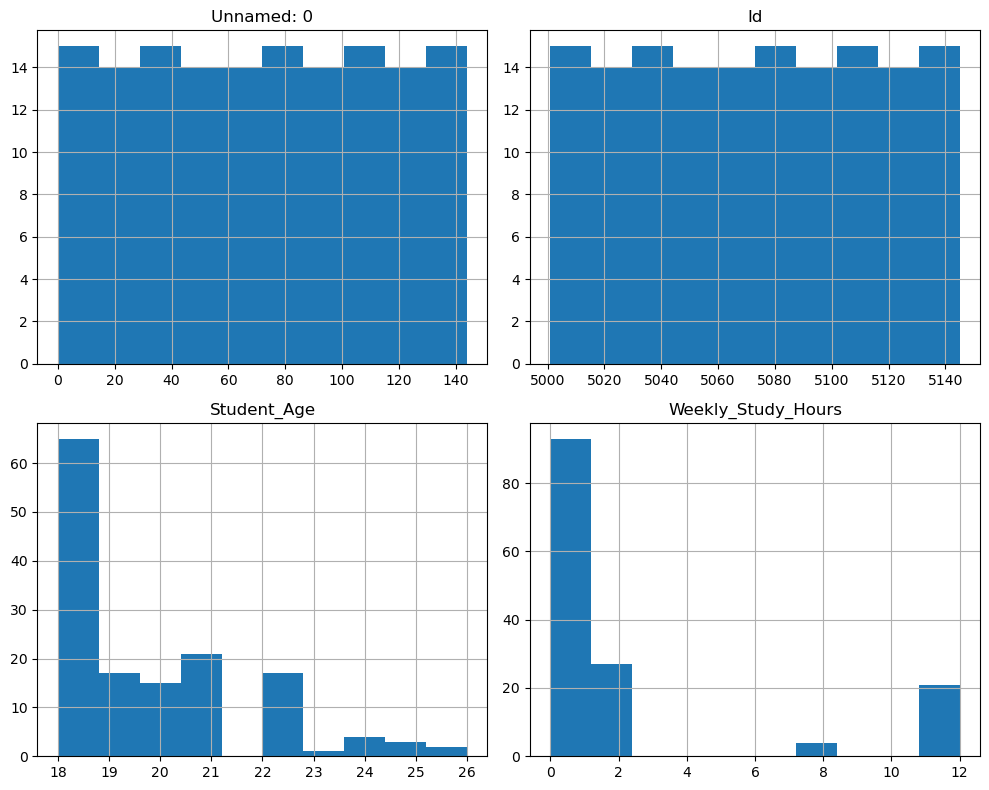

In [14]:
df[numerical_cols].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

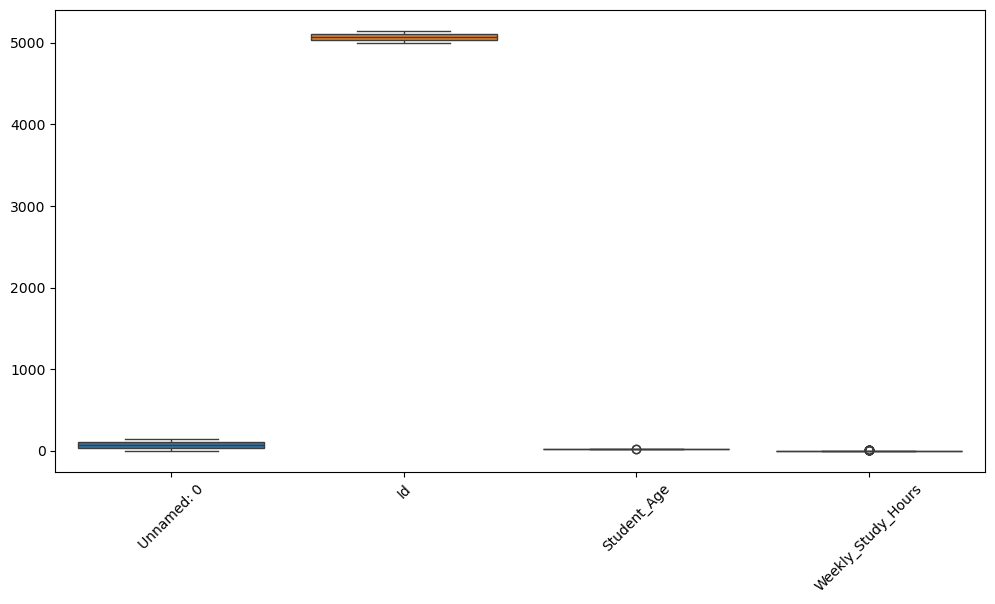

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.show()

In [17]:
df['Scholarship'].value_counts()

Scholarship
50%     77
75%     42
100%    23
25%      3
Name: count, dtype: int64

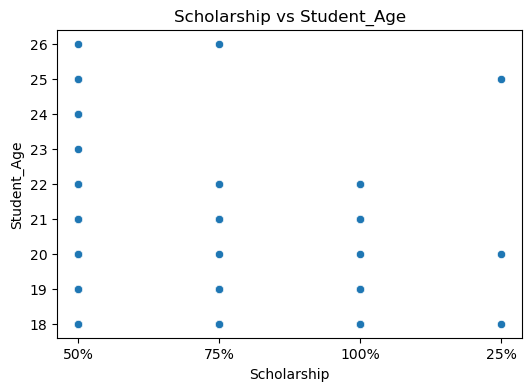

In [19]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Scholarship'], y=df['Student_Age'])
plt.title("Scholarship vs Student_Age")
plt.show()

In [20]:
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)

                    Unnamed: 0        Id  Student_Age  Weekly_Study_Hours
Unnamed: 0            1.000000  1.000000    -0.168406           -0.103421
Id                    1.000000  1.000000    -0.168406           -0.103421
Student_Age          -0.168406 -0.168406     1.000000            0.166730
Weekly_Study_Hours   -0.103421 -0.103421     0.166730            1.000000


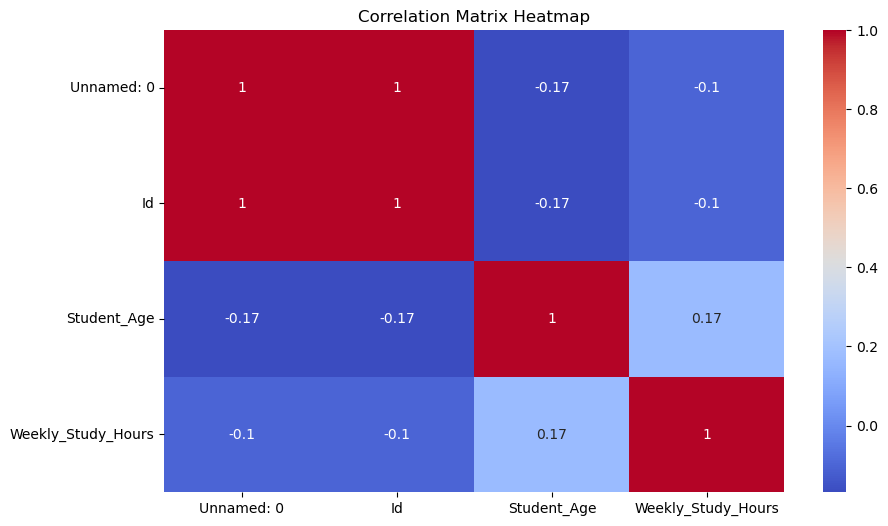

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()